# Wall hit statistics

This notebook rolls out the selected variant-2 models on the validation episodes and compares how often each policy attempts an invalid movement.

In [6]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch


NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "statistic" else NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import rainbow_dqn
from environment_v5 import Environment_v5
from environment_v13 import Environment_v13
from environment_v14 import Environment_v14
from environment_v15 import Environment_v15


DATA_DIR = PROJECT_ROOT / "data"
MODEL_ROOT = PROJECT_ROOT / "models2"
VARIANT = 2
NUM_VALIDATION_EPISODES = 100

ACTION_NAMES = {
    0: "stay",
    1: "up",
    2: "right",
    3: "down",
    4: "left",
}

RUNS = [
    {
        "name": "DQN v8.13.2 + env13",
        "short_name": "v8.13.2",
        "env_class": Environment_v13,
        "model_path": MODEL_ROOT / "DQN_v8.13.2_variant_2.pt",
        "color": "tab:blue",
    },
    {
        "name": "DQN v8.5.31 + env5",
        "short_name": "v8.5.31",
        "env_class": Environment_v5,
        "model_path": MODEL_ROOT / "DQN_v8.5.31_variant_2.pt",
        "color": "tab:orange",
    },
    {
        "name": "DQN v8.14.1 + env14",
        "short_name": "v8.14.1",
        "env_class": Environment_v14,
        "model_path": MODEL_ROOT / "DQN_v8.14.1_variant_2.pt",
        "color": "tab:green",
    },
    {
        "name": "DQN v8.15.1 + env15",
        "short_name": "v8.15.1",
        "env_class": Environment_v15,
        "model_path": MODEL_ROOT / "DQN_v8.15.1_variant_2.pt",
        "color": "tab:purple",
    },
]


print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir: {DATA_DIR}")
print(f"Model root: {MODEL_ROOT}")

Project root: /Users/zlr/Documents/CodingLab：DRL/CodingLab_DRL_team
Data dir: /Users/zlr/Documents/CodingLab：DRL/CodingLab_DRL_team/data
Model root: /Users/zlr/Documents/CodingLab：DRL/CodingLab_DRL_team/models2


In [7]:
def intended_location(loc, action):
    row, col = loc
    if action == 1:
        return (row - 1, col)
    if action == 2:
        return (row, col + 1)
    if action == 3:
        return (row + 1, col)
    if action == 4:
        return (row, col - 1)
    return loc


def invalid_move_kind(env, intended_loc):
    row, col = intended_loc
    if row < 0 or row >= env.vertical_cell_count or col < 0 or col >= env.horizontal_cell_count:
        return "boundary"
    if intended_loc not in env.eligible_cells:
        return "blocked_cell"
    return "unknown"


def load_policy(env, model_path):
    network = rainbow_dqn.DQN_v8(env)
    network.device = torch.device("cpu")
    network.support = network.support.to(network.device)
    network.q_network.to(network.device)
    network.target_network.to(network.device)

    state_dict = torch.load(model_path, map_location=network.device)
    network.q_network.load_state_dict(state_dict)
    network.q_network.eval()
    network.epsilon = 0
    return network


def rollout_wall_hits(run, episode_ids):
    env = run["env_class"](variant=VARIANT, data_dir=str(DATA_DIR))
    policy = load_policy(env, run["model_path"])
    episode_rows = []
    hit_rows = []
    visit_grid = np.zeros((env.vertical_cell_count, env.horizontal_cell_count), dtype=int)

    for validation_episode, episode_id in enumerate(episode_ids, start=1):
        env.validation_episodes = [int(episode_id)]
        env.validation_episode_counter = 0
        obs = env.reset("validation")
        visit_grid[env.agent_loc] += 1

        total_reward = 0.0
        wall_hits = 0
        boundary_hits = 0
        blocked_cell_hits = 0
        wall_hits_at_target = 0
        wall_hits_elsewhere = 0
        stay_actions = 0
        move_actions = 0

        for step in range(1, env.episode_steps + 1):
            before_loc = env.agent_loc
            action = int(policy.select_action(obs))

            if action == 0:
                stay_actions += 1
            else:
                move_actions += 1

            target_loc = intended_location(before_loc, action)
            reward, next_obs, done = env.step(action)
            after_loc = env.agent_loc
            visit_grid[after_loc] += 1
            total_reward += reward

            if action != 0 and after_loc == before_loc:
                wall_hits += 1
                kind = invalid_move_kind(env, target_loc)
                boundary_hits += kind == "boundary"
                blocked_cell_hits += kind == "blocked_cell"
                wall_hits_at_target += before_loc == env.target_loc
                wall_hits_elsewhere += before_loc != env.target_loc
                hit_rows.append({
                    "model": run["name"],
                    "short_name": run["short_name"],
                    "episode_id": int(episode_id),
                    "step": step,
                    "from_row": before_loc[0],
                    "from_col": before_loc[1],
                    "intended_row": target_loc[0],
                    "intended_col": target_loc[1],
                    "action": action,
                    "action_name": ACTION_NAMES[action],
                    "kind": kind,
                    "at_target": before_loc == env.target_loc,
                })

            obs = next_obs
            if done:
                break

        episode_rows.append({
            "model": run["name"],
            "short_name": run["short_name"],
            "episode_id": int(episode_id),
            "validation_episode": validation_episode,
            "total_reward": total_reward,
            "wall_hits": wall_hits,
            "boundary_hits": boundary_hits,
            "blocked_cell_hits": blocked_cell_hits,
            "wall_hits_at_target": wall_hits_at_target,
            "wall_hits_elsewhere": wall_hits_elsewhere,
            "stay_actions": stay_actions,
            "move_actions": move_actions,
        })

    return pd.DataFrame(episode_rows), pd.DataFrame(hit_rows), visit_grid


episode_ids = pd.read_csv(DATA_DIR / f"variant_{VARIANT}" / "validation_episodes.csv")["validation_episodes"].head(NUM_VALIDATION_EPISODES)
episode_frames = []
hit_frames = []
visit_grids = {}

for run in RUNS:
    print(f"Rolling out {run['name']}...")
    episode_df, hit_df, visit_grid = rollout_wall_hits(run, episode_ids)
    episode_frames.append(episode_df)
    hit_frames.append(hit_df)
    visit_grids[run["name"]] = visit_grid

wall_hit_by_episode = pd.concat(episode_frames, ignore_index=True)
wall_hit_events = pd.concat(hit_frames, ignore_index=True)

summary = wall_hit_by_episode.groupby(["model", "short_name"], as_index=False).agg(
    episodes=("episode_id", "count"),
    total_reward=("total_reward", "sum"),
    average_reward=("total_reward", "mean"),
    total_wall_hits=("wall_hits", "sum"),
    average_wall_hits=("wall_hits", "mean"),
    median_wall_hits=("wall_hits", "median"),
    total_boundary_hits=("boundary_hits", "sum"),
    total_blocked_cell_hits=("blocked_cell_hits", "sum"),
    total_wall_hits_at_target=("wall_hits_at_target", "sum"),
    total_wall_hits_elsewhere=("wall_hits_elsewhere", "sum"),
)

summary

Rolling out DQN v8.13.2 + env13...
Using device: cpu
Rolling out DQN v8.5.31 + env5...
Using device: cpu
Rolling out DQN v8.14.1 + env14...
Using device: cpu
Rolling out DQN v8.15.1 + env15...
Using device: cpu


,model,short_name,episodes,total_reward,average_reward,total_wall_hits,average_wall_hits,median_wall_hits,total_boundary_hits,total_blocked_cell_hits,total_wall_hits_at_target,total_wall_hits_elsewhere
0,DQN v8.13.2 + env13,v8.13.2,100,24864.5,248.645,3484,34.84,34.0,1794,1690,2955,529
1,DQN v8.14.1 + env14,v8.14.1,100,23990.0,239.900,6323,63.23,61.5,962,5361,5322,1001
2,DQN v8.15.1 + env15,v8.15.1,100,24036.0,240.360,6700,67.00,66.0,5413,1287,1920,4780
3,DQN v8.5.31 + env5,v8.5.31,100,24043.0,240.430,6311,63.11,63.0,5891,420,490,5821


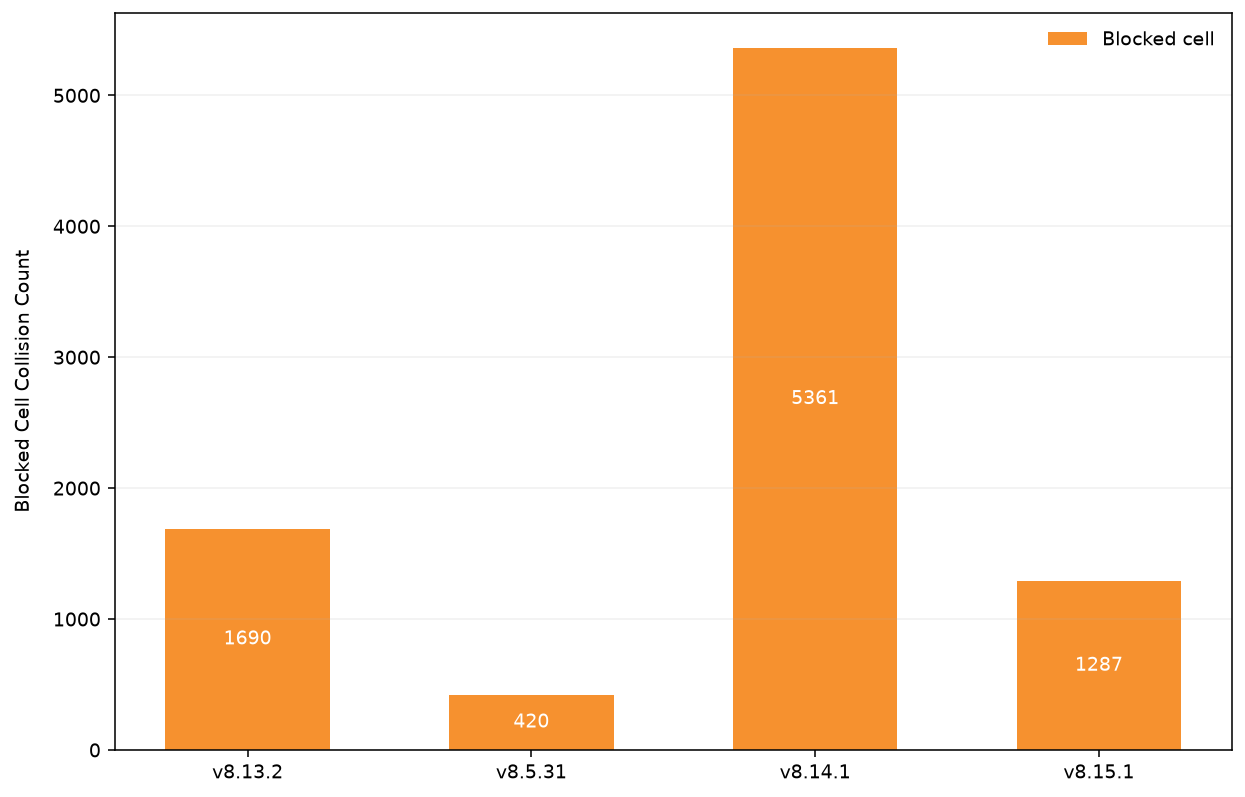

In [8]:
# Figure group 1: total blocked-cell hits
fig, ax = plt.subplots(figsize=(9, 5.8), dpi=140)
colors = {run["name"]: run["color"] for run in RUNS}
run_order = [run["name"] for run in RUNS]
short_labels = [run["short_name"] for run in RUNS]

totals = summary.set_index("model").loc[run_order]
blocked = totals["total_blocked_cell_hits"].to_numpy()
x = np.arange(len(run_order))

ax.bar(x, blocked, width=0.58, label="Blocked cell", color="#F58518", alpha=0.9)

for idx, blocked_value in enumerate(blocked):
    if blocked_value:
        ax.text(idx, blocked_value / 2, f"{int(blocked_value)}", ha="center", va="center", color="white", fontsize=10)

ax.set_ylabel("Blocked Cell Collision Count", labelpad=10)
ax.set_xticks(x, short_labels)
ax.grid(axis="y", linestyle="-", alpha=0.18)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


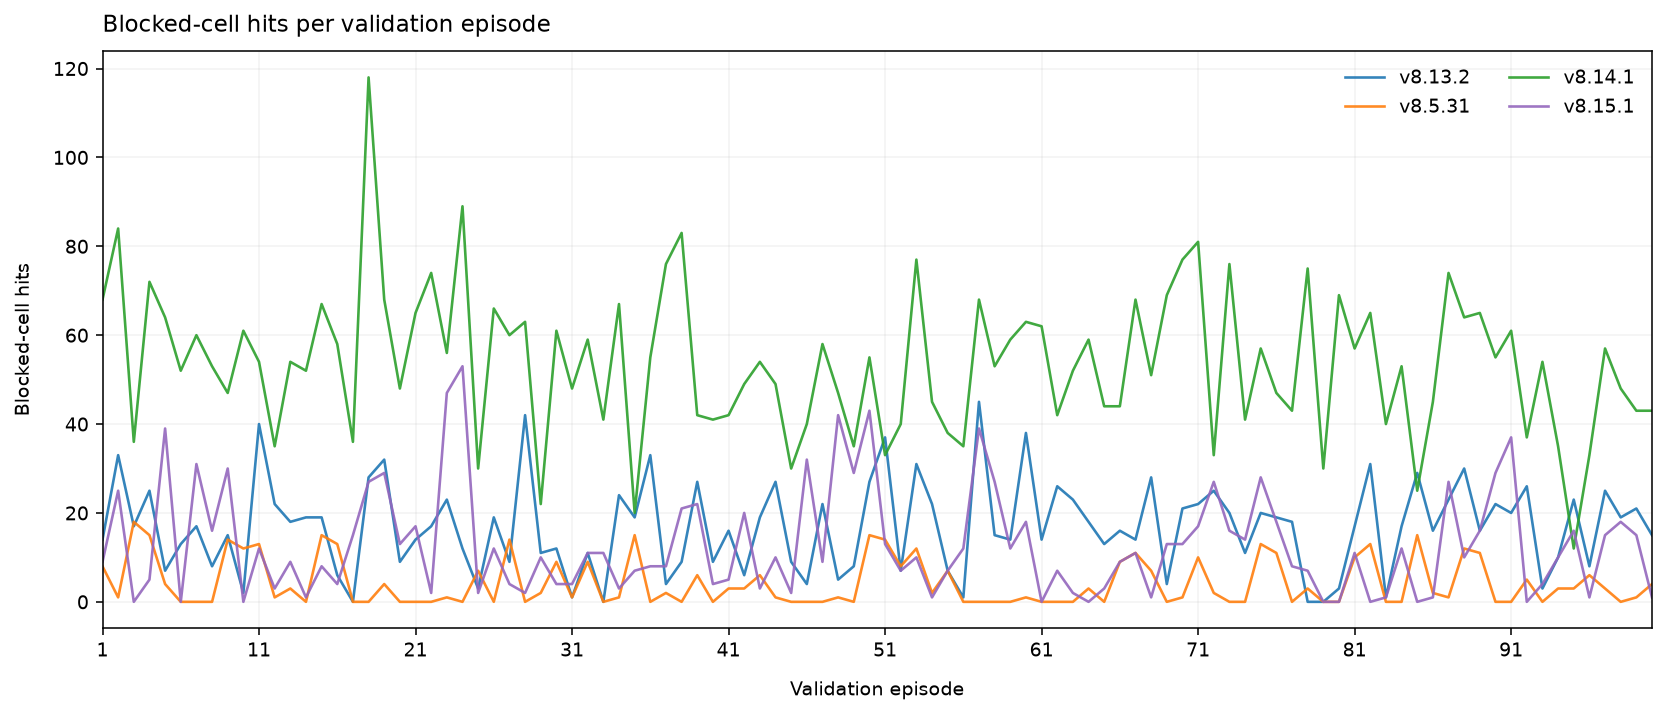

In [9]:
# Figure group 2: blocked-cell hits in each of the 100 validation episodes
fig, ax = plt.subplots(figsize=(12, 5.2), dpi=140)

for run in RUNS:
    rows = wall_hit_by_episode[wall_hit_by_episode["model"] == run["name"]].sort_values("validation_episode")
    ax.plot(
        rows["validation_episode"],
        rows["blocked_cell_hits"],
        label=run["short_name"],
        color=run["color"],
        linewidth=1.35,
        alpha=0.9,
    )

ax.set_title("Blocked-cell hits per validation episode", loc="left", pad=10)
ax.set_ylabel("Blocked-cell hits", labelpad=10)
ax.set_xlabel("Validation episode", labelpad=10)
ax.set_xlim(1, NUM_VALIDATION_EPISODES)
ax.set_xticks(range(1, NUM_VALIDATION_EPISODES + 1, 10))
ax.grid(axis="both", linestyle="-", alpha=0.16)
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()


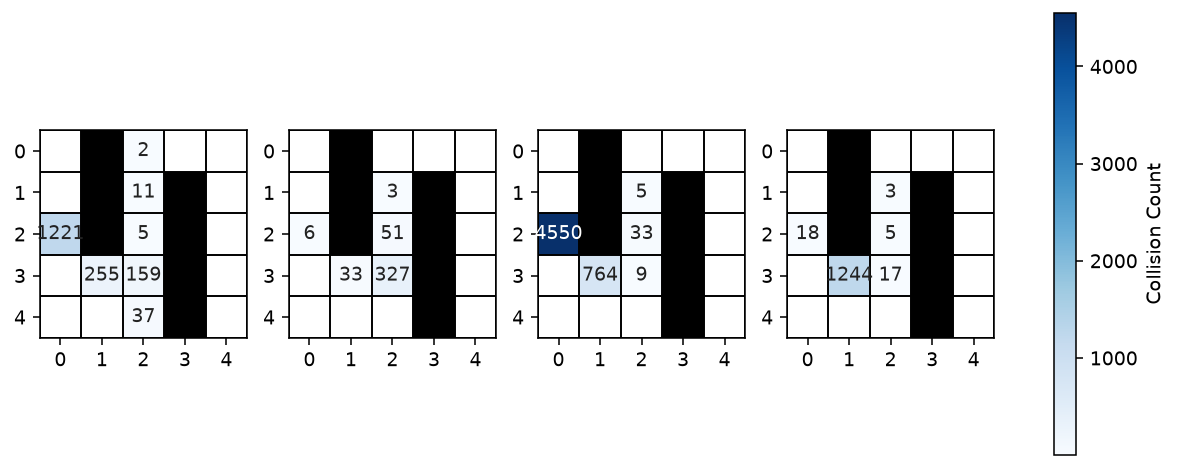

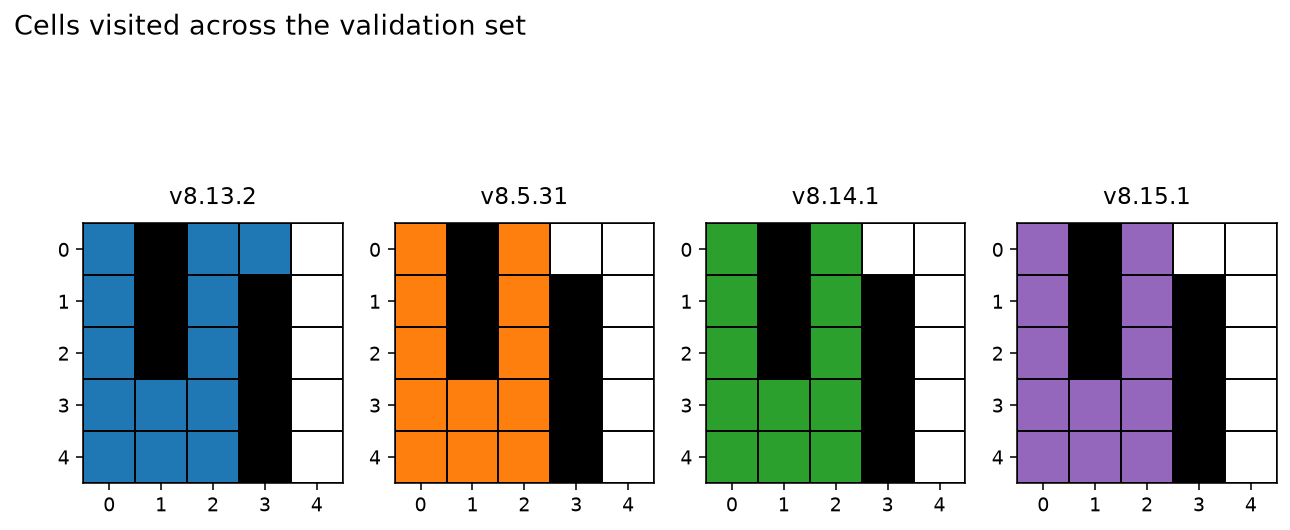

In [10]:
# Figure group 3: origin cells of blocked-cell hits
def hit_heatmap(events, run_name, hit_kind):
    grid = np.zeros((5, 5), dtype=int)
    rows = events[(events["model"] == run_name) & (events["kind"] == hit_kind)]
    for row, col in zip(rows["from_row"], rows["from_col"]):
        if 0 <= row < 5 and 0 <= col < 5:
            grid[int(row), int(col)] += 1
    return grid


def blocked_cell_mask(run):
    env = run["env_class"](variant=VARIANT, data_dir=str(DATA_DIR))
    eligible = set(env.eligible_cells)
    return np.array([
        [(row, col) not in eligible for col in range(5)]
        for row in range(5)
    ], dtype=bool)


hit_kind = "blocked_cell"
grids = {
    run["name"]: hit_heatmap(wall_hit_events, run["name"], hit_kind)
    for run in RUNS
}
vmax = max(grid.max() for grid in grids.values())
blocked_masks = {run["name"]: blocked_cell_mask(run) for run in RUNS}
cmap = plt.cm.Blues.copy()
cmap.set_under("white")
cmap.set_bad("black")

fig, axes = plt.subplots(1, len(RUNS), figsize=(11, 5), dpi=140)
for ax, run in zip(axes, RUNS):
    grid = grids[run["name"]]
    blocked_mask = blocked_masks[run["name"]]
    display_grid = np.ma.array(grid.astype(float), mask=blocked_mask)
    image = ax.imshow(display_grid, cmap=cmap, vmin=1, vmax=max(1, vmax))
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_xticks(np.arange(-0.5, 5, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 5, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=1.0)
    ax.tick_params(which="minor", bottom=False, left=False)
    for grid_row in range(5):
        for grid_col in range(5):
            value = grid[grid_row, grid_col]
            if value > 0 and not blocked_mask[grid_row, grid_col]:
                text_color = "white" if vmax and value > vmax * 0.45 else "#222222"
                ax.text(grid_col, grid_row, str(value), ha="center", va="center", color=text_color, fontsize=10)

fig.colorbar(image, ax=axes, shrink=0.82, label="Collision Count")
plt.show()


# Figure group 4: cells visited by each model across the validation set
fig, axes = plt.subplots(1, len(RUNS), figsize=(11, 5), dpi=140)
for ax, run in zip(axes, RUNS):
    visited = visit_grids[run["name"]] > 0
    blocked_mask = blocked_masks[run["name"]]
    display_grid = np.ma.array(visited.astype(float), mask=blocked_mask)
    visit_cmap = plt.matplotlib.colors.ListedColormap(["white", run["color"]])
    visit_cmap.set_bad("black")
    ax.imshow(display_grid, cmap=visit_cmap, vmin=0, vmax=1)
    ax.set_title(run["short_name"], pad=10)
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_xticks(np.arange(-0.5, 5, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 5, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=1.0)
    ax.tick_params(which="minor", bottom=False, left=False)

fig.suptitle("Cells visited across the validation set", x=0.08, ha="left", fontsize=14)
plt.show()
